# Ecuación de onda

## Expansión en modos normales

$y(x,t) = \sum_{n=1}^{\infty} B_n \sin\left(\frac{n \pi x}{L}\right) \cos\left(\frac{n \pi c t}{L}\right)$

### Determinar los coeficientes $B_n$

$B_n = \frac{2}{L} \int_0^L f(x) \sin\left(\frac{n \pi x}{L}\right) dx$ 

Donde $f(x)$ es la condición inicial de desplazamiento. Esto nos permite comparar la solución analítica con la solución numérica obtenida mediante métodos computacionales.

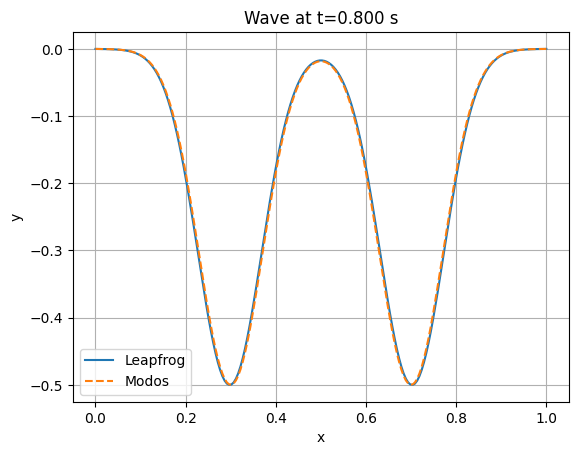

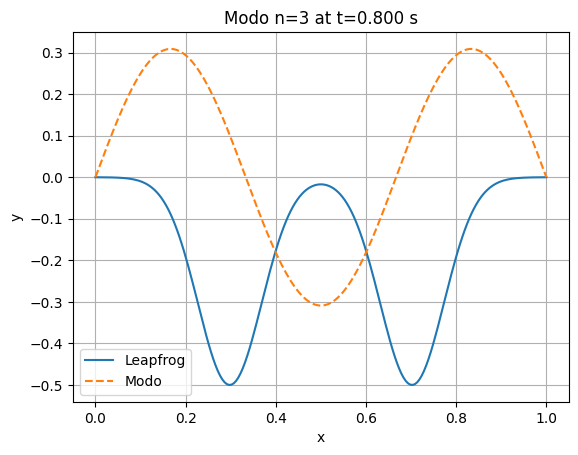

In [14]:
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
c = 1.0
Nx = 200
dx = L/(Nx-1)
dt = 0.004
Nt = 600
x = np.linspace(0, L, Nx)
y = np.zeros((Nt, Nx))

y[1,:] = np.exp(-100*(x-0.5)**2)
y[0,:] = y[1,:]
r = (c*dt/dx)**2

for j in range(1, Nt-1):
    for i in range(1, Nx-1):
        y[j+1,i]=(2*y[j,i] - y[j-1,i] + r * (y[j,i+1] - 2*y[j,i] + y[j,i-1]))

def fourier_modes(x, t, L, N):
    y = np.zeros_like(x)
    for n in range(1, N+1):
        Bn = 2*np.trapezoid(np.exp(-100*(x-0.5)**2)*np.sin(n*np.pi*x/L), x)/L
        wn = n*np.pi*c/L
        y += Bn * np.sin(n*np.pi*x/L) * np.cos(wn*t)
    return y

t_index = 200
t_val = t_index * dt

y_fourier = fourier_modes(x, t_val, L, 50)

plt.plot(x, y[t_index,:], label='Leapfrog')
plt.plot(x, y_fourier, '--', label='Modos')
plt.title(f'Wave at t={t_val:.3f} s')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

# Excitar un solo modo: 
# y[1,:] = np.sin(np.pi*x/L)

n_mode = 3
y[1,:] = np.sin(n_mode*np.pi*x/L)
y[0,:] = y[1,:]

plt.plot(x, y[t_index,:], label='Leapfrog')
plt.plot(x, np.sin(n_mode*np.pi*x/L)*np.cos(n_mode*np.pi*c*t_val/L), '--', label='Modo')
plt.title(f'Modo n={n_mode} at t={t_val:.3f} s')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()


## Fuerza de fricción

Se introduce una fuerza disipativa: 

$F_{f} = -2\kappa \Delta x \frac{\partial y}{\partial t}$

- $\kappa$ es el coeficiente de fricción. Mide la viscosidad del medio.
- Opuesta al movimiento

### Ecuación de onda con fricción

Aplicando la segunda ley de Newton:

$ \rho \frac{\partial^2 y}{\partial t^2} = T \frac{\partial^2 y}{\partial x^2} - 2\kappa \frac{\partial y}{\partial t}$

Dividiendo entre $\rho$:

$ \frac{\partial^2 y}{\partial t^2} + \frac{2\kappa}{\rho} \frac{\partial y}{\partial t} = c^2 \frac{\partial^2 y}{\partial x^2}$

Donde $\gamma = \frac{2\kappa}{\rho}$ es el coeficiente de amortiguamiento.

## Discretización de la ecuación de onda con fricción (Leapfrog)

$\frac{y_{i,j+1} - 2y_{i,j} + y_{i,j-1}}{\Delta t^2} + \gamma \frac{y_{i,j} - y_{i,j-1}}{\Delta t} = c^2 \frac{y_{i+1,j} - 2y_{i,j} + y_{i-1,j}}{\Delta x^2}$

Despejando: 

$y_{i,j+1} = \left(2 - \gamma \Delta t\right) y_{i,j} - \left(1 - \gamma \Delta t\right) y_{i,j-1} + c^2 \frac{\Delta t^2}{\Delta x^2} \left(y_{i+1,j} - 2y_{i,j} + y_{i-1,j}\right)$

Predicciones físicas

- $\gamma > 0$: Amortiguamiento, la onda pierde energía con el tiempo.
- $\gamma = 0$: Sin fricción, la onda se propaga sin pérdida de energía.
- $\gamma < 0$: Amplificación, la onda gana energía con el tiempo (no es físicamente realista).

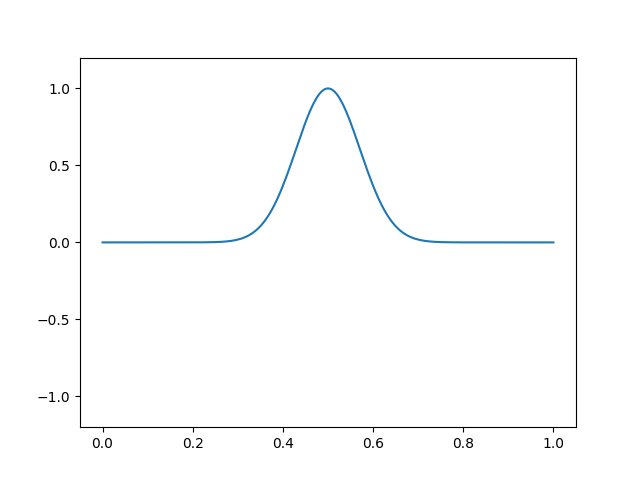

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

L = 1.0
c = 1.0
Nx = 200
dx = L/(Nx-1)
dt = 0.004
Nt = 800

gamma = 1.0 # Coeficiente de amortiguamiento

x = np.linspace(0, L, Nx)
y = np.zeros((Nt, Nx))

y[1,:] = np.exp(-100*(x-0.5)**2)
y[0,:] = y[1,:]
r = (c*dt/dx)**2

for j in range(1, Nt-1):
    y[j+1,1:-1] = (
        (2 - gamma*dt)*y[j,1:-1] 
        - (1 - gamma*dt)*y[j-1,1:-1] 
        + r * (y[j,2:] - 2*y[j,1:-1] + y[j,:-2])
    )

# Animación
# matplotlib widget
fig, ax = plt.subplots()
line, = ax.plot(x, y[0,:])
ax.set_ylim(-1.2, 1.2)

def update(frame):
    line.set_ydata(y[frame,:])
    ax.set_title(f'Time = {frame*dt:.3f} s')
    return line,

ani = FuncAnimation(fig, update, frames=Nt, interval=20, blit=True)

plt.show()